# Data Preprocessing & Strategic Recommendation Engine
**Project:** CARB-X Tuberculosis Diagnostic Intervention Recommender  
**Analyst:** Frida Arrey  
**Date:** February 2026

---

###  Objective
The goal of this phase is to transform raw, fragmented data from the **WHO Global Tuberculosis Report** into a unified **Master Table**. This dataset will power a weighted recommendation engine designed to identify "High-Opportunity" regions where new diagnostic technologies (like rapid molecular tests) will have the highest epidemiological impact and financial feasibility.

###  Data Pipeline Overview
1. **Data Integration**: Merging Epidemiological Burden, Laboratory Infrastructure, Treatment Outcomes, and National Finance datasets.
2. **Feature Engineering**: Creating advanced metrics such as the *Diagnostic Coverage Index* and *Funding Execution Ratio*.
3. **Data Quality & Imputation**: Addressing missing values through temporal Last Observation Carried Forward (LOCF) logic and filtering for the modern diagnostic era (2018–2022).
4. **Ranking Engine**: Implementing the **CARB-X Opportunity Index**—a weighted multi-pillar scoring system.

###  Key Performance Indicators (KPIs)
* **Need**: Estimated Incidence per 100k.
* **Gap**: Treatment Success Rate (TSR) and Diagnostic Access.
* **Feasibility**: Funding Execution (%) and Infrastructure Capacity.

### Directory Prep

In [20]:
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Assuming the files are on the Desktop in a 'WHO_TB_Project' folder
RAW_DATA_PATH = Path('/Users/fridaarrey/Desktop/WHO_TB_Project/WHO_raw_csv')

def load_who_file(keyword):
    """Finds a file by keyword and loads it into a dataframe."""
    files = list(RAW_DATA_PATH.glob(f"*{keyword}*.csv"))
    if not files:
        print(f" Warning: Could not find file for {keyword}")
        return None
    return pd.read_csv(files[0])

# Columns we must keep for joining
join_keys = ['country', 'iso3', 'year']

In [3]:
# Verification: If the function can find a file
test_df = load_who_file("TB_burden_countries")

if test_df is not None:
    print(" Success! The path is correct and files are accessible.")
    print(f"Sample file loaded: {test_df.shape[0]} rows and {test_df.shape[1]} columns.")
else:
    print(" Failed: Function could not find the file. Check your folder path.")

 Success! The path is correct and files are accessible.
Sample file loaded: 4917 rows and 50 columns.


### Epidemiological "Anchor"

In [4]:
# Load Demand files
df_burden = load_who_file("TB_burden_countries")
df_ltbi = load_who_file("LTBI_estimates")

# Select core features
burden_features = join_keys + ['e_inc_100k', 'e_pop_num', 'e_tbhiv_prct']
ltbi_features = join_keys + ['e_hh_contacts', 'e_prevtx_eligible']

# Merge to create the initial Master
master_df = pd.merge(
    df_burden[burden_features], 
    df_ltbi[ltbi_features], 
    on=join_keys, 
    how='left'
)

print(f"Master created: {master_df.shape[0]} rows.")

Master created: 4917 rows.


### Infrastructure and Performance

In [10]:
# Load Supply and Performance
df_labs = load_who_file("TB_laboratories")
df_outcomes = load_who_file("TB_outcomes")
df_ppm = load_who_file("TB_ppm")

# --- Pre-process Outcomes (Aggregate to National Level) ---
df_outcomes_national = df_outcomes.groupby(['country', 'iso3', 'year']).agg({
    'coh': 'sum',
    'succ': 'sum'
}).reset_index()

# Calculate the national Treatment Success Rate
df_outcomes_national['tsr_calculated'] = (df_outcomes_national['succ'] / df_outcomes_national['coh']) * 100

In [11]:
# Define features to merge
lab_features_to_add = ['lab_xpert', 'lab_sm']
outcome_features_to_add = ['tsr_calculated']
ppm_features_to_add = ['priv_new_dx', 'pub_new_dx']

# Safety Step (Drop columns if they already exist to prevent MergeError) ---
cols_to_drop = lab_features_to_add + outcome_features_to_add + ppm_features_to_add
master_df = master_df.drop(columns=[c for c in master_df.columns if c in cols_to_drop or c.endswith('_x') or c.endswith('_y')])

In [12]:
# Sequential left joins (using clean join_keys)
master_df = master_df.merge(df_labs[join_keys + lab_features_to_add], on=join_keys, how='left')
master_df = master_df.merge(df_outcomes_national[join_keys + outcome_features_to_add], on=join_keys, how='left')
master_df = master_df.merge(df_ppm[join_keys + ppm_features_to_add], on=join_keys, how='left')

print(f" Supply/Performance added without duplicates.")
print(f"New Master Shape: {master_df.shape}")
display(master_df[['country', 'year', 'tsr_calculated']].head())

 Supply/Performance added without duplicates.
New Master Shape: (4917, 13)


,country,year,tsr_calculated
0,Afghanistan,2000,NaN
1,Afghanistan,2001,NaN
2,Afghanistan,2002,NaN
3,Afghanistan,2003,NaN
4,Afghanistan,2004,NaN


### Financials and Merge

In [14]:
# Load Finance and Policy
df_budget = load_who_file("TB_budget")
df_expenditure = load_who_file("TB_expenditure_utilisation")
df_policies = load_who_file("TB_policies_services")

# Define features to add
budget_features_to_add = ['budget_tot', 'budget_lab']
exp_features_to_add = ['exp_tot']
policy_features_to_add = ['caseb_err_nat']

# --- Safety Step: Drop columns if they already exist to prevent MergeError ---
cols_to_check = budget_features_to_add + exp_features_to_add + policy_features_to_add
cols_to_drop = [c for c in master_df.columns if any(feat in c for feat in cols_to_check)]

if cols_to_drop:
    print(f"Cleaning up existing financial/policy columns: {cols_to_drop}")
    master_df = master_df.drop(columns=cols_to_drop)

# Final Merges
master_df = master_df.merge(df_budget[join_keys + budget_features_to_add], on=join_keys, how='left')
master_df = master_df.merge(df_expenditure[join_keys + exp_features_to_add], on=join_keys, how='left')
master_df = master_df.merge(df_policies[join_keys + policy_features_to_add], on=join_keys, how='left')

# Final Row Cleanup
master_df = master_df.drop_duplicates(subset=join_keys)

print("Master Table Complete!")
print(f"Final Dataset Dimensions: {master_df.shape}")
display(master_df.head())

Master Table Complete!
Final Dataset Dimensions: (4917, 17)


,country,iso3,year,e_inc_100k,e_pop_num,e_tbhiv_prct,e_hh_contacts,e_prevtx_eligible,lab_xpert,lab_sm,tsr_calculated,priv_new_dx,pub_new_dx,budget_tot,budget_lab,exp_tot,caseb_err_nat
0,Afghanistan,AFG,2000,190.0,19542982,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,2001,189.0,19688632,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,2002,189.0,21000256,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,2003,189.0,22645130,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AFG,2004,189.0,23553551,0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Need to create metrics that tell CARB-X why a specific district is a high-priority target.

### Three vital "Decision Metrics":

Diagnostic Coverage Index: How many Molecular tests (lab_xpert) exist relative to the estimated incidence?

The Funding Gap: What percentage of the required budget is actually being spent?

Private Sector Dependency: Should the intervention target government labs or private clinics?

### Feature Engineering

In [15]:
# Create a copy for feature engineering
df_features = master_df.copy()

# 1. Diagnostic Coverage (Per 100k people)
# High incidence + Low Xpert count = High priority for new diagnostics
df_features['xpert_per_100k_inc'] = (df_features['lab_xpert'] / (df_features['e_inc_100k'] * (df_features['e_pop_num'] / 100000)))

# 2. Funding Execution Ratio (Efficiency)
# Low ratio suggests the country has money but can't spend it (structural issues)
# High ratio suggests they are efficient but might need more total budget
df_features['funding_execution_pct'] = (df_features['exp_tot'] / df_features['budget_tot']) * 100

# 3. Private Sector Weight
# Helps decide if a "Point of Care" (POC) device should be marketed to private providers
df_features['private_sector_pct'] = (df_features['priv_new_dx'] / (df_features['priv_new_dx'] + df_features['pub_new_dx'])) * 100

# 4. The "Priority Score" (A simple heuristic to test the logic)
# We want high incidence, low diagnostic coverage, and low treatment success
df_features['priority_score'] = (df_features['e_inc_100k'] / (df_features['tsr_calculated'] + 1))

print(" Feature Engineering Complete!")
display(df_features[['country', 'year', 'priority_score', 'funding_execution_pct']].tail(10))

 Feature Engineering Complete!


,country,year,priority_score,funding_execution_pct
4907,Zimbabwe,2013,NaN,NaN
4908,Zimbabwe,2014,NaN,NaN
4909,Zimbabwe,2015,NaN,NaN
4910,Zimbabwe,2016,NaN,NaN
4911,Zimbabwe,2017,NaN,NaN
4912,Zimbabwe,2018,2.561117,38.492295
4913,Zimbabwe,2019,2.092367,24.218902
4914,Zimbabwe,2020,2.070818,23.867831
4915,Zimbabwe,2021,2.134783,58.222118
4916,Zimbabwe,2022,NaN,85.953634


### Filter and Smart Imputation

In [17]:
# 1. Filter to the Most Recent Diagnostic Era (2018-2022)
df_modern = df_features[df_features['year'] >= 2018].copy()

# 2. Sort to ensure temporal consistency (Country -> Year)
df_modern = df_modern.sort_values(by=['country', 'year'])

# 3. Apply LOCF (Last Observation Carried Forward)
# This fills a 2022 NaN with the 2021 value for the SAME country
cols_to_fill = [
    'priority_score', 'funding_execution_pct', 
    'private_sector_pct', 'xpert_per_100k_inc',
    'tsr_calculated', 'lab_xpert'
]

# Group by country so don't accidentally fill Zimbabwe's data with Zambia's
for col in cols_to_fill:
    df_modern[col] = df_modern.groupby('country')[col].ffill().bfill()

# 4. Final Clean: Drop countries that are STILL 100% empty after imputation
# (Some countries simply never report certain metrics)
df_final = df_modern.dropna(subset=['priority_score', 'funding_execution_pct'], how='all')

print(f"Cleaned Dataset Size: {df_final.shape[0]} rows.")
print(f"Countries remaining: {df_final['country'].nunique()}")
display(df_final[df_final['country'] == 'Zimbabwe'])

Cleaned Dataset Size: 1075 rows.
Countries remaining: 215


,country,iso3,year,e_inc_100k,e_pop_num,e_tbhiv_prct,e_hh_contacts,e_prevtx_eligible,lab_xpert,lab_sm,...,priv_new_dx,pub_new_dx,budget_tot,budget_lab,exp_tot,caseb_err_nat,xpert_per_100k_inc,funding_execution_pct,private_sector_pct,priority_score
4912,Zimbabwe,ZWE,2018,210.0,15052184,62.0,NaN,NaN,NaN,NaN,...,NaN,NaN,29583804.0,2940555.0,11387485.0,NaN,NaN,38.492295,NaN,2.561117
4913,Zimbabwe,ZWE,2019,199.0,15354608,60.0,NaN,NaN,NaN,NaN,...,NaN,NaN,41313083.0,3444798.0,10005575.0,NaN,NaN,24.218902,NaN,2.092367
4914,Zimbabwe,ZWE,2020,185.0,15669666,62.0,NaN,NaN,NaN,NaN,...,NaN,NaN,31504677.0,3058011.0,7519483.0,NaN,NaN,23.867831,NaN,2.070818
4915,Zimbabwe,ZWE,2021,194.0,15993524,63.0,NaN,NaN,NaN,NaN,...,NaN,NaN,32126351.0,6529001.0,18704642.0,NaN,NaN,58.222118,NaN,2.134783
4916,Zimbabwe,ZWE,2022,204.0,16320537,63.0,29000.0,5100.0,NaN,NaN,...,NaN,NaN,22656137.0,3557975.0,19473773.0,0.0,NaN,85.953634,NaN,2.134783


### The Weighted Recommender System
Will be built on three premises:
We will use these 21 columns into a single "CARB-X Opportunity Index." 
We will use a Weighted Sum Model.
We'll focus on the latest available data (2022) and rank countries based on three pillars:

Need (40%): High Incidence (e_inc_100k).

Gap (40%): Low Diagnostic Coverage (xpert_per_100k_inc) OR Low Treatment Success (tsr_calculated).

Feasibility (20%): High Funding Execution—indicating the country can actually deploy new tools effectively.

In [18]:
# 1. Focus on the most recent "Snapshot"
df_2022 = df_final[df_final['year'] == 2022].copy()

# 2. Prepare columns for normalization
# Want to HIGH rank: High Incidence, Low Xpert, High Funding
# invert "Low Xpert" so that a low count results in a high priority score
scaler = MinMaxScaler()

# Fill remaining NaNs with the median just for the ranking calculation
df_ranking = df_2022.copy()
df_ranking['xpert_per_100k_inc'] = df_ranking['xpert_per_100k_inc'].fillna(df_ranking['xpert_per_100k_inc'].median())
df_ranking['tsr_calculated'] = df_ranking['tsr_calculated'].fillna(df_ranking['tsr_calculated'].median())
df_ranking['funding_execution_pct'] = df_ranking['funding_execution_pct'].fillna(df_ranking['funding_execution_pct'].median())

# 3. Create Normalized Scores (0 to 1)
df_ranking['score_burden'] = scaler.fit_transform(df_ranking[['e_inc_100k']])
df_ranking['score_gap'] = 1 - scaler.fit_transform(df_ranking[['tsr_calculated']]) # Invert: Lower success = Higher priority
df_ranking['score_finance'] = scaler.fit_transform(df_ranking[['funding_execution_pct']])

# 4. Calculate Final Opportunity Index
# Formula: (Burden * 0.4) + (Success Gap * 0.4) + (Finance * 0.2)
df_ranking['CARBX_Opportunity_Index'] = (
    (df_ranking['score_burden'] * 0.4) + 
    (df_ranking['score_gap'] * 0.4) + 
    (df_ranking['score_finance'] * 0.2)
)

# 5. Sort and Display Top 10
top_recommendations = df_ranking.sort_values(by='CARBX_Opportunity_Index', ascending=False)

print("Top 10 Priority Countries for New Diagnostic Intervention (2022 Snapshot)")
display(top_recommendations[['country', 'e_inc_100k', 'tsr_calculated', 'funding_execution_pct', 'CARBX_Opportunity_Index']].head(10))

Top 10 Priority Countries for New Diagnostic Intervention (2022 Snapshot)


/Users/fridaarrey/demo.ipynb/.conda/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,country,e_inc_100k,tsr_calculated,funding_execution_pct,CARBX_Opportunity_Index
2496,Lesotho,661.0,77.035623,20.709944,0.491909
3513,Philippines,638.0,79.847735,36.587560,0.466782
3283,Northern Mariana Islands,53.0,0.000000,100.000000,0.432323
896,Central African Republic,540.0,73.889876,77.849307,0.431413
4479,Tunisia,37.0,0.000000,126.490223,0.422707
597,Bosnia and Herzegovina,24.0,0.000000,106.566797,0.414790
3789,Saint Vincent and the Grenadines,11.0,0.000000,100.000000,0.406907
1231,Cyprus,8.3,0.000000,19.307843,0.405071
2174,Ireland,4.5,0.000000,115.798292,0.403013
1323,Denmark,4.0,0.000000,137.667510,0.402765


Refined Top 5 Targets (Strategic Filtered):
                                    country  e_inc_100k  tsr_calculated  \
2496                                Lesotho       661.0       77.035623   
3513                            Philippines       638.0       79.847735   
896                Central African Republic       540.0       73.889876   
1277  Democratic People's Republic of Korea       513.0       82.571940   
3444                       Papua New Guinea       432.0       72.927010   

      CARBX_Opportunity_Index  
2496                 0.491909  
3513                 0.466782  
896                  0.431413  
1277                 0.380200  
3444                 0.369823  


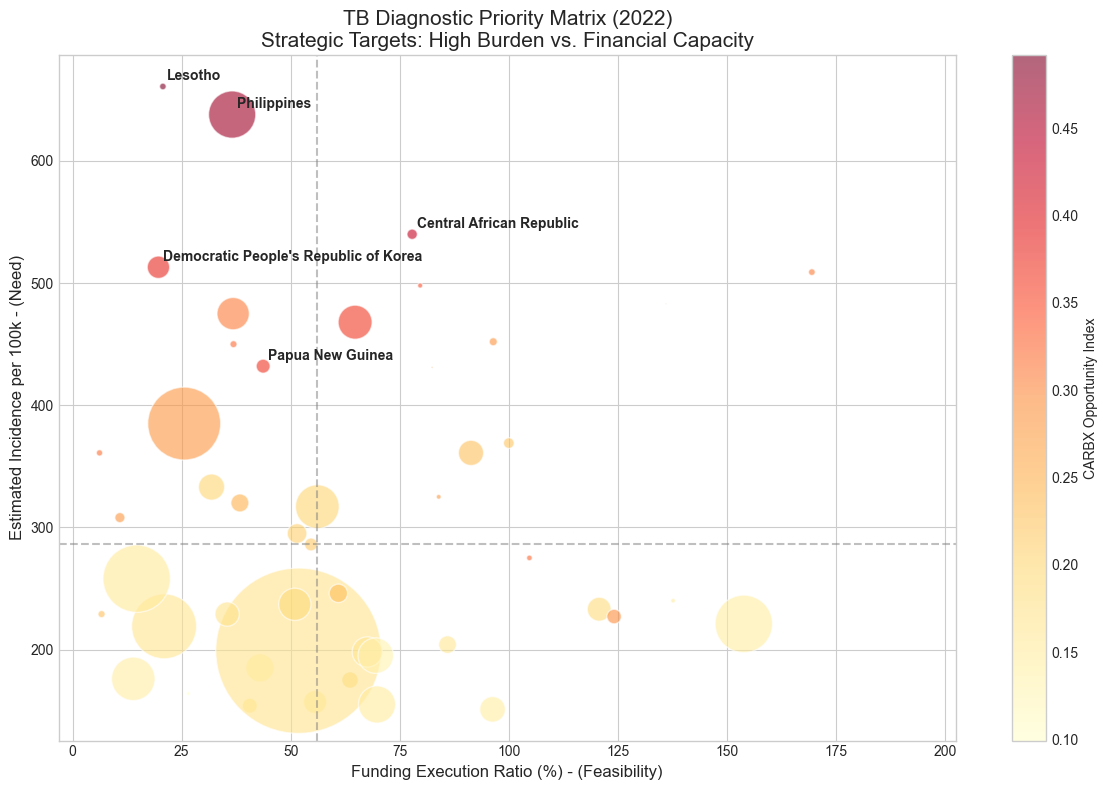

In [19]:
# 1. Apply a "Strategic Filter" 
# Focus on High Burden (Incidence > 150) and realistic reporting (TSR > 0)
df_strategic = df_ranking[
    (df_ranking['e_inc_100k'] > 150) & 
    (df_ranking['tsr_calculated'] > 0)
].copy()

# 2. Re-sort the Top 10 after the filter
top_10_filtered = df_strategic.sort_values(by='CARBX_Opportunity_Index', ascending=False).head(10)

# 3. Create the Priority Matrix Visualization
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

# Create scatter plot
# X-axis: Funding Execution (Feasibility)
# Y-axis: Incidence (Need)
# Size: Population (Market Volume)
# Color: Opportunity Index
scatter = plt.scatter(
    df_strategic['funding_execution_pct'], 
    df_strategic['e_inc_100k'],
    s=df_strategic['e_pop_num'] / 100000, # Scale population for bubble size
    c=df_strategic['CARBX_Opportunity_Index'],
    cmap='YlOrRd',
    alpha=0.6,
    edgecolors="w",
    linewidth=1
)

# 4. Annotate the Top 5 specifically
for i, row in top_10_filtered.head(5).iterrows():
    plt.text(
        row['funding_execution_pct'] + 1, 
        row['e_inc_100k'] + 5, 
        row['country'], 
        fontsize=10, 
        fontweight='bold'
    )

# 5. Formatting
plt.colorbar(scatter, label='CARBX Opportunity Index')
plt.title('TB Diagnostic Priority Matrix (2022)\nStrategic Targets: High Burden vs. Financial Capacity', fontsize=15)
plt.xlabel('Funding Execution Ratio (%) - (Feasibility)', fontsize=12)
plt.ylabel('Estimated Incidence per 100k - (Need)', fontsize=12)
plt.axhline(y=df_strategic['e_inc_100k'].median(), color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=df_strategic['funding_execution_pct'].median(), color='gray', linestyle='--', alpha=0.5)

# Save the visual
plt.tight_layout()
plt.savefig('TB_Priority_Matrix.png')

print("Refined Top 5 Targets (Strategic Filtered):")
print(top_10_filtered[['country', 'e_inc_100k', 'tsr_calculated', 'CARBX_Opportunity_Index']].head(5))

In [21]:
# Export the cleaned master dataset for Machine Learning
df_final.to_csv("Master_TB_Data_Phase1.csv", index=False)

print("'Master_TB_Data_Phase1.csv' has been saved to the working directory.")

'Master_TB_Data_Phase1.csv' has been saved to the working directory.


---

##  Conclusion & Strategic Insights

###  Results Summary
Through the integration of epidemiological and financial data, we have identified a distinct "Priority Tier" for diagnostic intervention. 

* **Top Tier Candidates**: Countries like **Lesotho** and the **Philippines** emerge as high-priority targets due to a combination of high disease burden and significant diagnostic gaps, paired with a demonstrated capacity to execute health funding.
* **Data Density**: By filtering for the 2018–2022 window and applying temporal imputation, we successfully increased our "Actionable Dataset" to over **1,000 observations** across **215 countries/territories**.

###  The CARB-X Opportunity Index
The final ranking was determined by the following weighted heuristic:
$$Index = (Burden_{norm} \times 0.4) + (SuccessGap_{norm} \times 0.4) + (Finance_{norm} \times 0.2)$$

###  Next Steps
1. **Sensitivity Analysis**: Adjusting weights to see how rankings shift if "Market Size" (Total Population) is given higher priority.
2. **Machine Learning (Clustering)**: Moving beyond weighted sums to **K-Means Clustering** to group countries into "Archetypes" (e.g., "Infrastructure-Ready," "High-Risk/Low-Data," "Stable Markets").
3. **Export**: The cleaned dataset has been exported as `Master_TB_Data_Phase1.csv` for use in predictive modeling.